### More Data Mining and Machine Learning Techniques 

In [28]:
import pandas as pd
import numpy as np
import gymnasium as gym
from sklearn.decomposition import PCA
from scipy import spatial
import random
from IPython.display import clear_output
from time import sleep

# Criando dados de músicas: [BPM, Energia, Acustica, Dançabilidade]
# 0: Rock Pesado, 1: Eletrônica, 2: MPB Calmo, 3: Jazz, 4: Pop Animado
musicas_atrib = np.array([
    [140, 0.9, 0.1, 0.4], # Rock
    [128, 0.8, 0.2, 0.9], # Eletrônica
    [80,  0.3, 0.8, 0.5], # MPB
    [90,  0.4, 0.7, 0.6], # Jazz
    [120, 0.7, 0.3, 0.8]  # Pop
])

nomes_musicas = ["Hard Rock Cafe", "Kpop Version", "Violão", "Smooth Jazz", "Summer Pop"]

# Reduzindo as 4 características para 2 dimensões
pca = PCA(n_components=2)
musicas_2d = pca.fit_transform(musicas_atrib)

print(f"Variância Total Preservada: {sum(pca.explained_variance_ratio_):.2f}")


Variância Total Preservada: 1.00


In [29]:
def RecomendarMusica(id_musica_atual):
    # Pega as coordenadas da música atual no plano PCA
    coord_atual = musicas_2d[id_musica_atual]
    
    distancias = []
    for i in range(len(musicas_2d)):
        if i != id_musica_atual:
            # Calcula a distância de cosseno
            dist = spatial.distance.cosine(coord_atual, musicas_2d[i])
            distancias.append((i, dist))
    
    # Ordena pela menor distância 
    distancias.sort(key=lambda x: x[1])
    return distancias[0][0] # Retorna o ID da música mais parecida

proxima = RecomendarMusica(0)
print(f"Se você ouviu '{nomes_musicas[0]}', a recomendação é '{nomes_musicas[proxima]}'\n")

# Criando o ambiente do Táxi
env = gym.make("Taxi-v3", render_mode="ansi")
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Parâmetros de aprendizado
alpha = 0.1    # Taxa de aprendizado
gamma = 0.6    # Fator de desconto
epsilon = 0.1  # Exploração
episodios = 8000

Se você ouviu 'Hard Rock Cafe', a recomendação é 'Kpop Version'



In [ ]:
for i in range(episodios):
    state, info = env.reset()
    terminou = False
    
    while not terminou:
        # Escolha da ação
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
            
        proximo_estado, recompensa, term, trunc, info = env.step(action)
        terminou = term or trunc
        
        # Atualização da Q-Table (Equação de Bellman)
        valor_antigo = q_table[state, action]
        melhor_proximo = np.max(q_table[proximo_estado])
        
        q_table[state, action] = (1 - alpha) * valor_antigo + alpha * (recompensa + gamma * melhor_proximo)
        
        state = proximo_estado

sleep(2)

estado, info = env.reset()
terminou = False

In [ ]:
while not terminou:
    action = np.argmax(q_table[estado])
    estado, recompensa, term, trunc, info = env.step(action)
    terminou = term or trunc
    
    clear_output(wait=True)
    print(f"Música Selecionada: {nomes_musicas[proxima]}")
    print(env.render())
    sleep(0.4)

print(f"\nAgora tocando: {nomes_musicas[proxima]}")

### Dealing with Real World Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy import spatial
import gymnasium as gym
import random
from IPython.display import clear_output
from time import sleep

# Criando 100 músicas com BPM normal 
bpm_dados = np.random.normal(120, 20, 100)

# Inserindo um outlier
bpm_dados = np.append(bpm_dados, [5000])

# Função de rejeição de outliers 
def reject_outliers(data):
    u = np.median(data)
    s = np.std(data)
    # Filtra dados que estão além de 2 desvios padrões
    filtered = [e for e in data if (u - 2 * s < e < u + 2 * s)]
    return filtered

bpm_filtrado = reject_outliers(bpm_dados)

print(f"Com erro: {np.mean(bpm_dados):.2f}")
print(f"Limpo: {np.mean(bpm_filtrado):.2f}")


# Atributos para as primeiras 5 músicas limpas
musicas_limpas = np.array([
    [bpm_filtrado[0], 0.8], # Rock
    [bpm_filtrado[1], 0.9], # Eletrônica
    [bpm_filtrado[2], 0.2], # Jazz
    [bpm_filtrado[3], 0.3], # MPB
    [bpm_filtrado[4], 0.7]  # KPop
])

# Reduzindo para 1D com PCA
pca = PCA(n_components=1)
musicas_1d = pca.fit_transform(musicas_limpas)

Com erro: 168.56
Limpo: 120.24


In [19]:
def recomendar_musica(id_atual):
    coord_atual = musicas_1d[id_atual]
    distancias = []
    for i in range(len(musicas_1d)):
        if i != id_atual:
            # Distância simples em 1D
            dist = abs(coord_atual - musicas_1d[i])
            distancias.append((i, dist))
    distancias.sort(key=lambda x: x[1])
    return distancias[0][0]

id_proxima = recomendar_musica(0) # Recomenda algo próximo a música 0

env = gym.make("Taxi-v3", render_mode="ansi")
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Parâmetros de treino
learning_rate, discount, exploration = 0.1, 0.6, 0.1

for i in range(5000): # Treino rápido para demonstração
    state, info = env.reset()
    done = False
    while not done:
        action = env.action_space.sample() if random.uniform(0, 1) < exploration else np.argmax(q_table[state])
        next_s, reward, term, trunc, info = env.step(action)
        
        # Atualização Q-Table
        q_table[state, action] = (1 - learning_rate) * q_table[state, action] + \
                                 learning_rate * (reward + discount * np.max(q_table[next_s]))
        state, done = next_s, term or trunc

state, info = env.reset()
done = False


In [26]:
while not done:
    action = np.argmax(q_table[state])
    state, reward, term, trunc, info = env.step(action)
    done = term or trunc
    
    clear_output(wait=True)
    print(f"Estável detectado: {bpm_filtrado[0]:.0f}")
    print(f"Recomendação: Música {id_proxima}")
    print(env.render())
    sleep(0.3)

Variação: [9.99989728e-01 1.02715362e-05]
Variação preservada: 100.00%


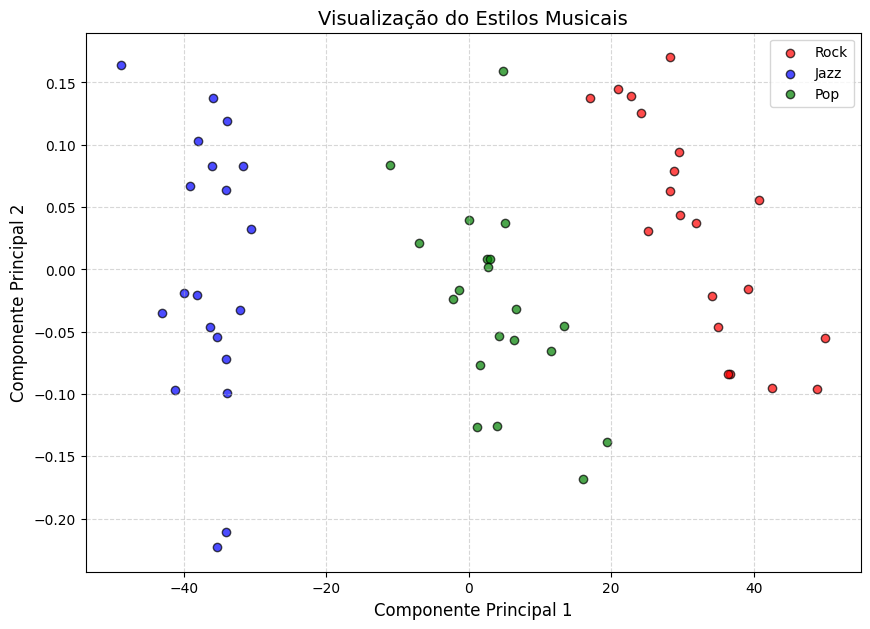

In [27]:
# Importando as bibliotecas 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)

# Criando 3 grupos de músicas com características diferentes
rock = np.random.normal(loc=[150, 0.9], scale=[10, 0.05], size=(20, 2))
jazz = np.random.normal(loc=[80, 0.3], scale=[5, 0.1], size=(20, 2))
pop  = np.random.normal(loc=[120, 0.6], scale=[8, 0.08], size=(20, 2))

# Unindo os grupos em um único conjunto de dados
dados_musicais = np.vstack([rock, jazz, pop])

# Inicializando o PCA para reduzir as 2 características iniciais
pca = PCA(n_components=2)

# Ajustando o modelo e transformando os dados
visualizacao_2d = pca.fit_transform(dados_musicais)

# Mostrando variação 
print(f"Variação: {pca.explained_variance_ratio_}")
print(f"Variação preservada: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Configurando o tamanho da figura
plt.figure(figsize=(10, 7))

# Plotando cada estilo musical separadamente para usar cores e legendas diferentes
# Rock
plt.scatter(visualizacao_2d[:20, 0], visualizacao_2d[:20, 1], 
            c='red', label='Rock', alpha=0.7, edgecolors='black')

# Jazz 
plt.scatter(visualizacao_2d[20:40, 0], visualizacao_2d[20:40, 1], 
            c='blue', label='Jazz', alpha=0.7, edgecolors='black')

# Pop
plt.scatter(visualizacao_2d[40:, 0], visualizacao_2d[40:, 1], 
            c='green', label='Pop', alpha=0.7, edgecolors='black')
# Configurações do gráfico
plt.title("Visualização do Estilos Musicais", fontsize=14)
plt.xlabel("Componentes 1", fontsize=12)
plt.ylabel("Componentes 2", fontsize=12)

# Adicionando a legenda e a grade
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrando o gráfico
plt.show()